In [140]:
import cv2
import matplotlib.pyplot as plt
from IPython.display import clear_output
from ultralytics import YOLO

In [141]:
model = YOLO("best.pt")

In [142]:
PPE_CLASSES = {
    0: "Hardhat",
    1: "Mask",
    2: "NO-Hardhat",
    3: "NO-Mask",
    4: "NO-Safety Vest",
    5: "Person",
    6: "Safety Cone",
    7: "Safety Vest",
    8: "Machinery",
    9: "Vehicle"
}

In [143]:
COLORS = {
    "Hardhat": (0,255,0),
    "Mask": (0,255,0),
    "Safety Vest": (0,255,0),
    "Person": (255,255,0),

    "NO-Hardhat": (0,0,255),
    "NO-Mask": (0,0,255),
    "NO-Safety Vest": (0,0,255),

    "Safety Cone": (255,0,255),
    "Machinery": (255,165,0),
    "Vehicle": (255,165,0)
}

In [144]:
video_path = "video-from-rawpixel-id-19297010-sd.mp4"

cap = cv2.VideoCapture(video_path)

In [145]:
success, frame = cap.read()

print(success)

True


In [146]:
results = model(frame)


0: 640x384 2 Hardhats, 2 NO-Hardhats, 5 NO-Safety Vests, 4 Persons, 1 Vehicle, 953.2ms
Speed: 19.9ms preprocess, 953.2ms inference, 10.8ms postprocess per image at shape (1, 3, 640, 384)


In [147]:
annotated = frame.copy()

for result in results:

    for box in result.boxes:

        class_id = int(box.cls[0])

        confidence = float(box.conf[0])

        label = PPE_CLASSES[class_id]

        x1, y1, x2, y2 = map(int, box.xyxy[0])

        color = COLORS.get(label,(255,255,255))

        cv2.rectangle(
            annotated,
            (x1,y1),
            (x2,y2),
            color,
            2
        )

        cv2.putText(
            annotated,
            f"{label} {confidence:.2f}",
            (x1,y1-5),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            color,
            2
        )

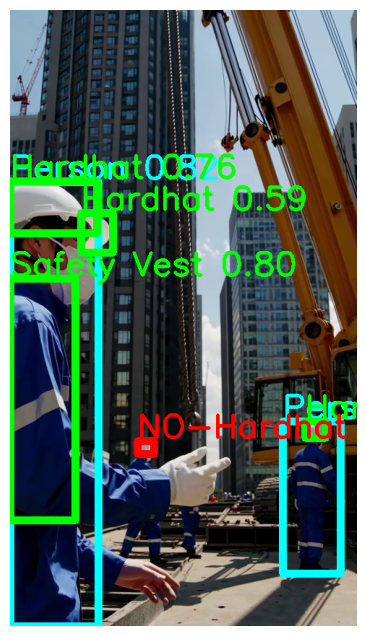

KeyboardInterrupt: 

In [148]:
while cap.isOpened():

    success, frame = cap.read()

    if not success:
        break

    results = model(frame)

    annotated = frame.copy()

    for result in results:

        for box in result.boxes:

            class_id = int(box.cls[0])

            confidence = float(box.conf[0])

            label = PPE_CLASSES[class_id]

            x1,y1,x2,y2 = map(int,box.xyxy[0])

            color = COLORS.get(label,(255,255,255))
            # Box thickness (10 pixels)
            box_thickness = 10

            # Font settings
            font = cv2.FONT_HERSHEY_SIMPLEX
            font_scale =1.5
            font_thickness = 3

            cv2.rectangle(
                annotated,
                (x1, y1),
                (x2, y2),
                color,
                box_thickness
            )

            cv2.putText(
                 annotated,
                f"{label} {confidence:.2f}",
                (x1, y1 - 5),
                font,
                font_scale,
                color,
                font_thickness,
            )

    clear_output(wait=True)

    plt.figure(figsize=(12,8))

    plt.imshow(cv2.cvtColor(annotated,cv2.COLOR_BGR2RGB))

    plt.axis("off")

    plt.show()

cap.release()